In [ ]:
import duckdb
import polars as pl
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

con = duckdb.connect("../data/m5.db")
con.execute("SHOW TABLES").fetchdf()
df = con.execute("SELECT * FROM dataset_raw LIMIT 5").fetchdf()

df

In [ ]:
con.execute("""
SELECT
    event_name,
    event_type,
    COUNT(*) AS n
FROM dataset_raw
WHERE event_name IS NOT NULL
GROUP BY 1, 2
ORDER BY 1
""").fetchdf()

In [ ]:
df_eventos = con.execute("""
WITH daily AS (
    SELECT
        CAST(date AS DATE) AS date,
        event_name,
        SUM(sales) AS sales
    FROM dataset_raw
    GROUP BY 1, 2
),

baseline AS (
    SELECT
        AVG(sales) AS avg_sales_normal
    FROM daily
    WHERE event_name IS NULL
),

event_summary AS (
    SELECT
        event_name,
        COUNT(*) AS n_days,
        AVG(sales) AS avg_sales_event,
        MIN(sales) AS min_sales,
        MAX(sales) AS max_sales
    FROM daily
    WHERE event_name IS NOT NULL
    GROUP BY event_name
)

SELECT
    e.event_name,
    e.n_days,
    ROUND(e.avg_sales_event, 2) AS avg_sales_event,
    ROUND(b.avg_sales_normal, 2) AS avg_sales_normal,

    ROUND(
        100.0 * (e.avg_sales_event / b.avg_sales_normal - 1),
        2
    ) AS pct_change_vs_normal

FROM event_summary e
CROSS JOIN baseline b
ORDER BY pct_change_vs_normal
""").fetchdf()

In [ ]:
df_eventos

In [ ]:
df_eventos_principales = con.execute("""
WITH daily AS (
    SELECT
        CAST(date AS DATE) AS date,
        SUM(sales) AS sales,
        MAX(event_name) AS event_name
    FROM dataset_raw
    GROUP BY 1
),

event_analysis AS (
    SELECT
        e.event_name,
        e.date AS event_date,

        AVG(
            CASE
                WHEN d.date BETWEEN e.date - INTERVAL 3 DAY
                                AND e.date - INTERVAL 1 DAY
                THEN d.sales
            END
        ) AS avg_sales_pre,

        e.sales AS sales_event,

        AVG(
            CASE
                WHEN d.date BETWEEN e.date + INTERVAL 1 DAY
                                AND e.date + INTERVAL 3 DAY
                THEN d.sales
            END
        ) AS avg_sales_post

    FROM daily e
    JOIN daily d
        ON d.date BETWEEN e.date - INTERVAL 3 DAY
                       AND e.date + INTERVAL 3 DAY

    WHERE e.event_name IN (
        'Thanksgiving',
        'NewYear',
        'Christmas',
        'Halloween',
        'Easter',
        'SuperBowl',
        'LaborDay',
        'Mother''s day',
        'Father''s day',
        'ValentinesDay'
    )

    GROUP BY
        e.event_name,
        e.date,
        e.sales
)

SELECT
    event_name,
    event_date,

    ROUND(avg_sales_pre, 2) AS avg_sales_pre,
    ROUND(sales_event, 2) AS sales_event,
    ROUND(avg_sales_post, 2) AS avg_sales_post,

    ROUND(
        100 * (sales_event / NULLIF(avg_sales_pre, 0) - 1),
        2
    ) AS pct_event_vs_pre,

    ROUND(
        100 * (avg_sales_post / NULLIF(sales_event, 0) - 1),
        2
    ) AS pct_post_vs_event

FROM event_analysis

ORDER BY event_name, event_date
""").fetchdf()

In [28]:
summary = (
    df_eventos_principales.groupby("event_name")
      .agg(
          avg_sales_pre=("avg_sales_pre", "mean"),
          avg_sales_event=("sales_event", "mean"),
          avg_sales_post=("avg_sales_post", "mean"),
      )
)

summary = summary.round(0).astype(int)


summary["var_pre_post"] = (
    (summary["avg_sales_pre"] / summary["avg_sales_post"] - 1)
)

summary.sort_values("var_pre_post", ascending=False, inplace=True)

summary

,avg_sales_pre,avg_sales_event,avg_sales_post,var_pre_post
event_name,,,,
Easter,40561,39518,32960,0.230613
LaborDay,40079,42155,32709,0.225320
Father's day,36086,36562,30076,0.199827
SuperBowl,37486,40924,31825,0.177879
Christmas,34367,16,31469,0.092091
ValentinesDay,38099,33496,34955,0.089944
Mother's day,36422,36111,33448,0.088914
Thanksgiving,32185,21130,30306,0.062001
NewYear,33533,25768,36804,-0.088876


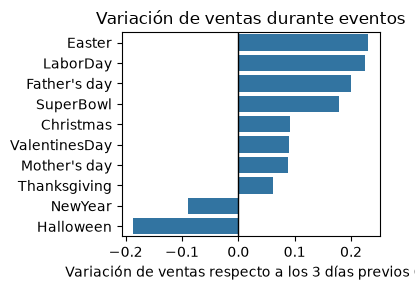

In [30]:
plt.figure(figsize=(4, 3))

sns.barplot(
    data=summary,
    x="var_pre_post",
    y="event_name"
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Variación de ventas respecto a los 3 días previos (%)")
plt.ylabel("")
plt.title("Variación de ventas durante eventos")

plt.tight_layout()
plt.show()